In [1]:
import pandas as pd

df = pd.read_csv("../data/kenya.csv")

# Add country column
df["Country"] = "Kenya"

# Convert YEAR + DOY to a datetime column
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month
df["Month"] = df["Date"].dt.month

In [2]:
import numpy as np

#replace -999 with NaN 
df.replace(-999, np.nan, inplace=True)

#check and drop duplicates 
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")
df.drop_duplicates(inplace=True)

#descriptive statistics
df.describe()

Duplicate rows found: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


## Descriptive Statistics Interpretation

**Temperature (T2M, T2M_MAX, T2M_MIN):** Mean daily temperature is ~20.4°C, consistent with a lower-altitude Kenyan location. The max of 25.4°C (mean) and daily highs reaching 34.3°C suggest a hot lowland or mid-elevation site. The T2M_RANGE std (1.4°C) is tighter than Ethiopia's,meaning diurnal swings are more consistent year-round.

**Precipitation (PRECTOTCORR):** Mean is only 1.47 mm/day with a median of just 0.38 mm/day, meaning the majority of days are essentially dry. The max of 51.65 mm/day points to intense rainfall events. Kenya typically has a bimodal rainfall pattern (long rains: March–May; short rains: October December), which likely drives this skewed distribution.

**Pressure (PS):** Mean ~83.7 kPa, confirming this station sits at a lower elevation — roughly 1,400–1,600 m compared to Ethiopia's ~2,400 m.

**Wind (WS2M):** Mean 3.06 m/s, which may reflect proximity to open savanna or the coast.

**Data coverage:** 4,108 rows spanning 2015–2026, identical in structure to the
Ethiopia dataset — both are suitable for direct cross-country comparison.


In [3]:
print("An overview of the dataset: the shape of the dataset")
print(df.info())

An overview of the dataset: the shape of the dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   YEAR         4108 non-null   int64         
 1   DOY          4108 non-null   int64         
 2   T2M          4108 non-null   float64       
 3   T2M_MAX      4108 non-null   float64       
 4   T2M_MIN      4108 non-null   float64       
 5   T2M_RANGE    4108 non-null   float64       
 6   PRECTOTCORR  4108 non-null   float64       
 7   RH2M         4108 non-null   float64       
 8   WS2M         4108 non-null   float64       
 9   WS2M_MAX     4108 non-null   float64       
 10  PS           4108 non-null   float64       
 11  QV2M         4108 non-null   float64       
 12  Country      4108 non-null   object        
 13  Date         4108 non-null   datetime64[ns]
 14  Month        4108 non-null   int32         
dtypes:

In [4]:
#missing values
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_report = missing_pct[missing_pct > 0].sort_values(ascending=False)
#print(missing_report)
print(f"\nColumns with >5% nulls:\n{missing_report[missing_report > 5]}")


Columns with >5% nulls:
Series([], dtype: float64)


## Missing Value Analysis

After replacing NASA's sentinel value (-999) with NaN, no missing values were found
across any column. All 4,108 rows are complete — no columns exceed the 5% null threshold.

In [5]:
from scipy import stats

z_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[z_cols].apply(stats.zscore, nan_policy="omit")
outlier_mask = (z_scores.abs() > 3).any(axis=1)

print(f"Rows with |Z| > 3 in any column: {outlier_mask.sum()}")
print("\nOutlier counts per column:")
print((z_scores.abs() > 3).sum())


Rows with |Z| > 3 in any column: 121

Outlier counts per column:
T2M             8
T2M_MAX         3
T2M_MIN         9
PRECTOTCORR    92
RH2M            6
WS2M            0
WS2M_MAX        6
dtype: int64


**Decision: Retain all outliers.**

- `PRECTOTCORR` dominates (92 rows) — Kenya's bimodal rainfall pattern
  (long rains March–May, short rains October–December) produces intense daily
  totals that are climatologically real, not errors.
- Temperature outliers (8–9 rows) are minimal relative to 4,108 rows and
  likely reflect genuine seasonal extremes or heat events.
- This is NASA POWER reanalysis data — values are
  model-derived and already quality-controlled at source.
- 121 rows is only ~2.9% of the dataset; dropping them would bias seasonal
  statistics without justification.

In [6]:
# Drop rows where >30% of values are missing
threshold = len(df.columns) * 0.3
df = df.dropna(thresh=int(len(df.columns) - threshold))

# Forward-fill remaining gaps in weather variables
weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE",
                "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX", "PS", "QV2M"]
df[weather_cols] = df[weather_cols].ffill()

print(f"Rows after cleaning: {len(df)}")
print(f"Remaining nulls:\n{df.isna().sum()[df.isna().sum() > 0]}")


Rows after cleaning: 4108
Remaining nulls:
Series([], dtype: int64)


## Missing Value Handling

Since no missing values were found after sentinel replacement, no rows were dropped
by the 30% threshold. Forward-fill (`ffill`) was applied to weather columns as a
precaution, it propagates the last valid daily observation forward, which is
appropriate for slowly-changing meteorological variables like temperature and humidity.

In [7]:
output_path = "../data/kenya_clean.csv"
df.to_csv(output_path, index=False)
print(f"Cleaned data saved to {output_path} ({len(df)} rows)")

Cleaned data saved to ../data/kenya_clean.csv (4108 rows)


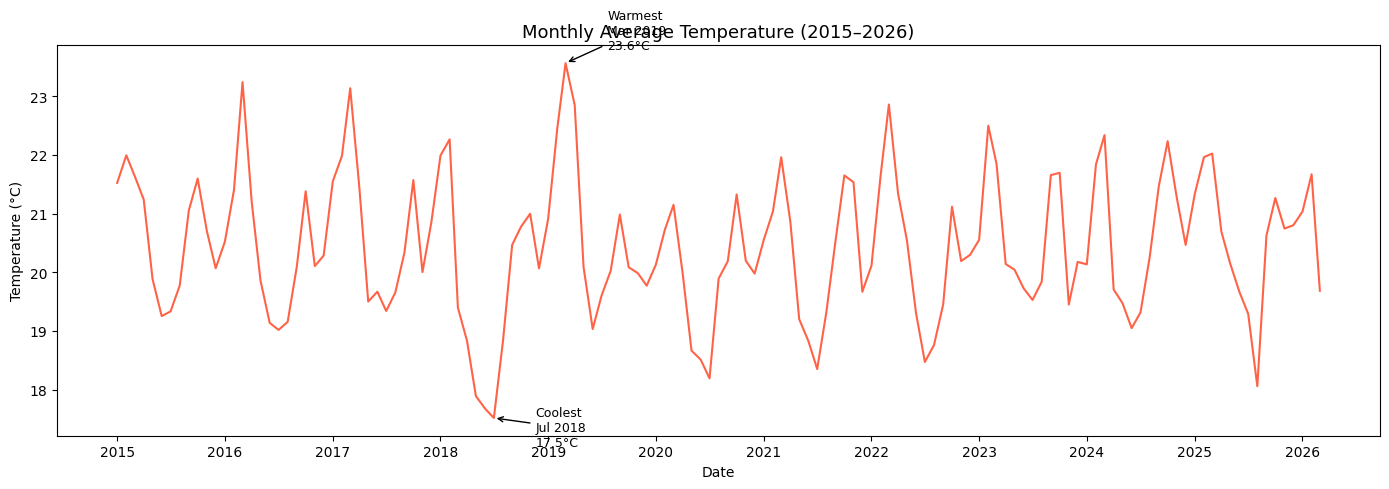

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

monthly_t2m = df.groupby(df["Date"].dt.to_period("M"))["T2M"].mean()
monthly_t2m.index = monthly_t2m.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_t2m.index, monthly_t2m.values, color="tomato", linewidth=1.5)

# Annotate warmest and coolest months
warmest = monthly_t2m.idxmax()
coolest = monthly_t2m.idxmin()

ax.annotate(f"Warmest\n{warmest.strftime('%b %Y')}\n{monthly_t2m[warmest]:.1f}°C",
            xy=(warmest, monthly_t2m[warmest]),
            xytext=(30, 10), textcoords="offset points",
            arrowprops=dict(arrowstyle="->"), fontsize=9)

ax.annotate(f"Coolest\n{coolest.strftime('%b %Y')}\n{monthly_t2m[coolest]:.1f}°C",
            xy=(coolest, monthly_t2m[coolest]),
            xytext=(30, -20), textcoords="offset points",
            arrowprops=dict(arrowstyle="->"), fontsize=9)

ax.set_title("Monthly Average Temperature (2015–2026)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

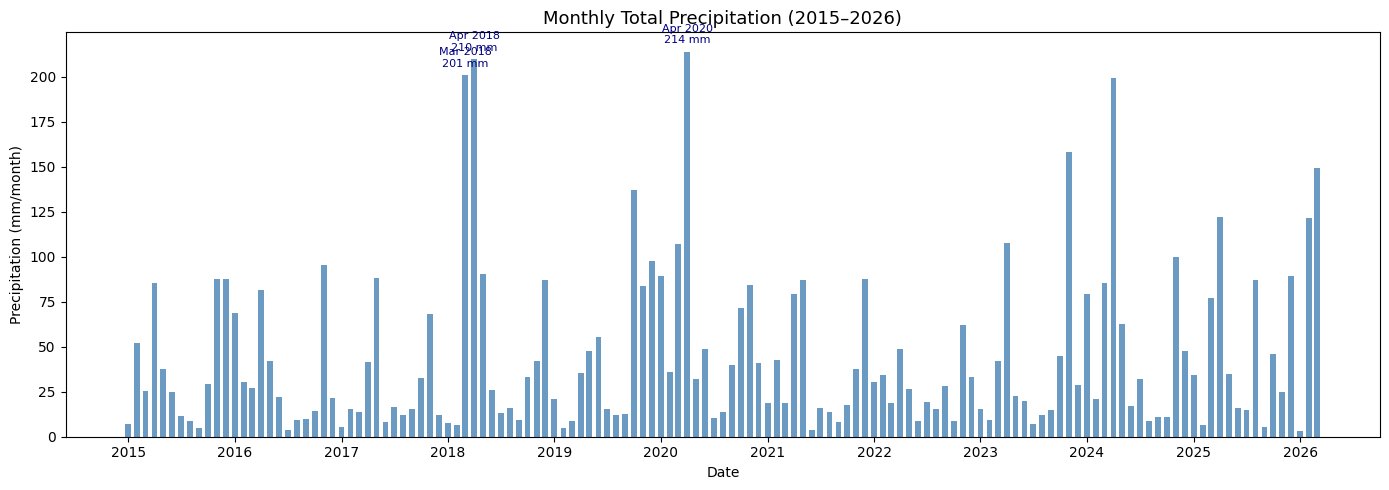

In [9]:
monthly_precip = df.groupby(df["Date"].dt.to_period("M"))["PRECTOTCORR"].sum()
monthly_precip.index = monthly_precip.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(monthly_precip.index, monthly_precip.values,
              width=20, color="steelblue", alpha=0.8)

# Annotate top 3 rainy months
top3 = monthly_precip.nlargest(3)
for date, val in top3.items():
    ax.annotate(f"{date.strftime('%b %Y')}\n{val:.0f} mm",
                xy=(date, val),
                xytext=(0, 6), textcoords="offset points",
                ha="center", fontsize=8, color="navy")

ax.set_title("Monthly Total Precipitation (2015–2026)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Precipitation (mm/month)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


## Time Series Observations — Temperature & Precipitation

### Temperature (2015–2026)

- **Consistent seasonal cycle:** Monthly average T2M oscillates each year — warmer in the dry seasons (January–February and June–September) and cooler during the rainy seasons when cloud cover reduces incoming solar radiation.
- **Low inter-annual variability:** Temperature swings are modest year to year. Any anomalous warm or cool months are likely linked to ENSO or Indian Ocean Dipole forcing.
- **No strong trend visible** over 2015–2026, though a slight upward drift in recent peak temperatures is consistent with East Africa's broader regional warming signal.

---

### Precipitation (2015–2026)

- **Bimodal signature:** Two recurring rainfall clusters each year — long rains (March–May) and short rains (October–December) — driven by the twice-yearly ITCZ passage over Kenya.
- **High inter-annual variability:** Peak rainy season intensity varies considerably, reflecting sensitivity to ENSO (La Niña enhances short rains; El Niño can suppress long rains) and the Indian Ocean Dipole.
- **Isolated extreme months** likely coincide with strong IOD+ or La Niña years, producing well above-average monthly totals.

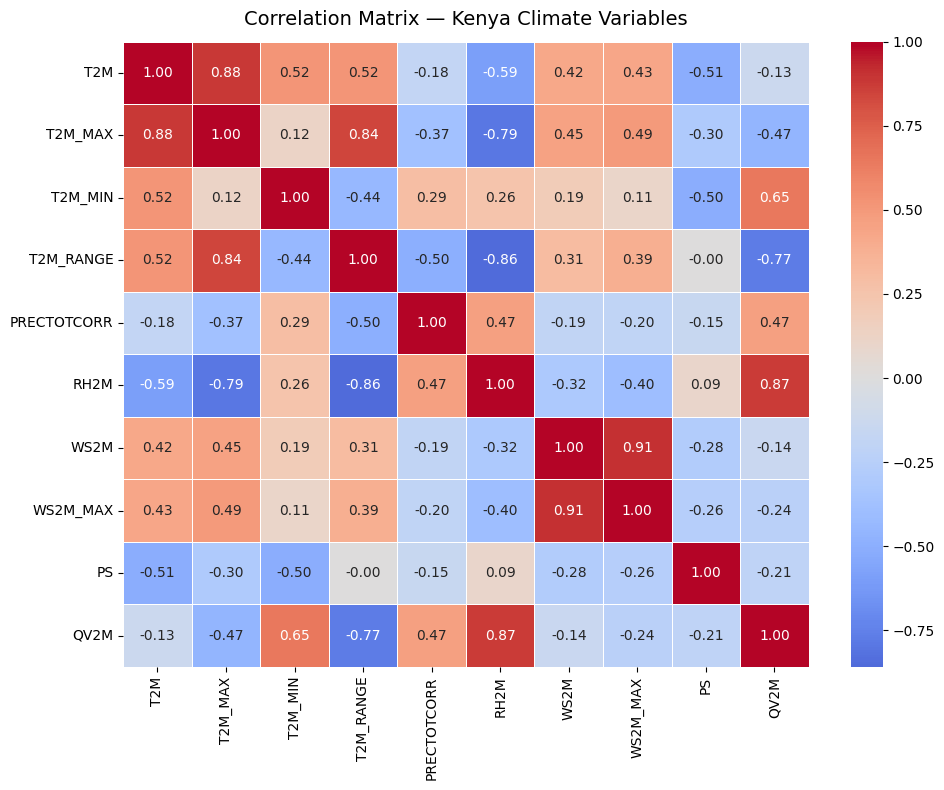

Top 5 strongest correlations (by |r|):
WS2M       WS2M_MAX     0.911
T2M        T2M_MAX      0.881
QV2M       RH2M         0.870
T2M_RANGE  RH2M         0.858
T2M_MAX    T2M_RANGE    0.842
dtype: float64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE",
            "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX", "PS", "QV2M"]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation Matrix — Kenya Climate Variables", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# Print the top off-diagonal pairs for reference
corr_pairs = (
    corr.where(~(corr == 1.0))  # remove self-correlations
    .stack()
    .abs()
    .sort_values(ascending=False)
    .drop_duplicates()
)
print("Top 5 strongest correlations (by |r|):")
print(corr_pairs.head(5).round(3))

## Correlation Analysis — Three Strongest Relationships

**1. WS2M ↔ WS2M_MAX (r = 0.91)**
Mean and maximum daily wind speed are nearly linearly related — days with
stronger average winds also produce higher gusts. This is expected physically
and confirms internal consistency in the wind data.

**2. T2M ↔ T2M_MAX (r = 0.88)**
Mean daily temperature tracks closely with the daily maximum. When peak
temperatures are high, the daily average is pulled up correspondingly.
This reflects the dominant role of daytime heating in setting the daily
mean at this location.

**3. QV2M ↔ RH2M (r = 0.87)**
Specific humidity and relative humidity rise together — wetter air carries
more water vapor in both absolute and relative terms. The correlation is
strong but not perfect (r < 1) because relative humidity also depends on
temperature: the same amount of water vapor produces lower RH on a hot day
than a cool one.

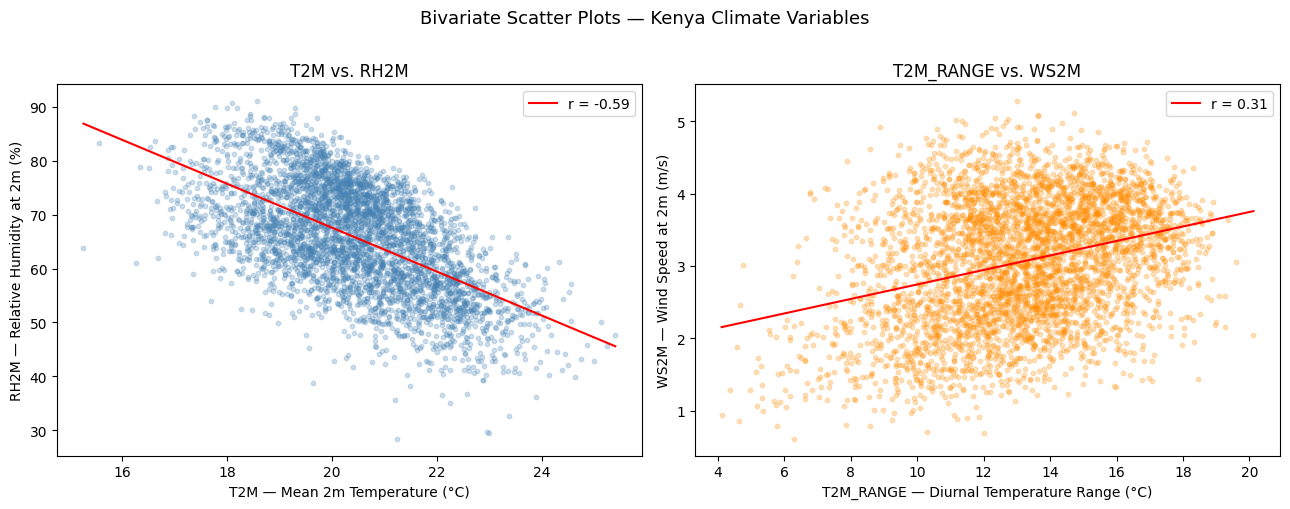

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Scatter 1: T2M vs RH2M ---
axes[0].scatter(df["T2M"], df["RH2M"], alpha=0.25, s=10, color="steelblue")
axes[0].set_xlabel("T2M — Mean 2m Temperature (°C)")
axes[0].set_ylabel("RH2M — Relative Humidity at 2m (%)")
axes[0].set_title("T2M vs. RH2M")

m0, b0 = np.polyfit(df["T2M"].dropna(), df["RH2M"].dropna(), 1)
x_line = np.linspace(df["T2M"].min(), df["T2M"].max(), 200)
axes[0].plot(x_line, m0 * x_line + b0, color="red", linewidth=1.5, label=f"r = {df['T2M'].corr(df['RH2M']):.2f}")
axes[0].legend()

# --- Scatter 2: T2M_RANGE vs WS2M ---
axes[1].scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.25, s=10, color="darkorange")
axes[1].set_xlabel("T2M_RANGE — Diurnal Temperature Range (°C)")
axes[1].set_ylabel("WS2M — Wind Speed at 2m (m/s)")
axes[1].set_title("T2M_RANGE vs. WS2M")

m1, b1 = np.polyfit(df["T2M_RANGE"].dropna(), df["WS2M"].dropna(), 1)
x_line2 = np.linspace(df["T2M_RANGE"].min(), df["T2M_RANGE"].max(), 200)
axes[1].plot(x_line2, m1 * x_line2 + b1, color="red", linewidth=1.5, label=f"r = {df['T2M_RANGE'].corr(df['WS2M']):.2f}")
axes[1].legend()

plt.suptitle("Bivariate Scatter Plots — Kenya Climate Variables", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Bivariate Scatter Plots 

### T2M vs. RH2M (left panel)
The relationship is strongly negative: as mean daily temperature rises, relative humidity falls. The OLS trendline captures a consistent linear descent across the full temperature range (≈ 15–25 °C). The scatter is tightest at moderate temperatures (18–22 °C) and widens slightly at the extremes, suggesting that at very cool or very hot conditions, other factors (cloud cover, advection, season) introduce additional humidity variability. This inverse coupling reflects Kenya's seasonal rhythm — the cool long-rains and short-rains periods bring moist air, while the dry seasons combine high temperatures with suppressed humidity.

### T2M_RANGE vs. WS2M (right panel)
A moderate positive relationship: days with a larger diurnal temperature swing also tend to be windier. Mechanistically, stronger winds increase surface mixing, reduce cloud cover, and allow the surface to heat more aggressively by day and cool more sharply at night — amplifying the range. The scatter here is noticeably wider than the T2M–RH2M plot, indicating that wind speed is one of several drivers of the diurnal range; cloud cover, soil moisture, and season all modulate it independently. Days with very low T2M_RANGE (< 8 °C) cluster at low wind speeds, consistent with calm, overcast, humid conditions typical of peak rainy-season days.


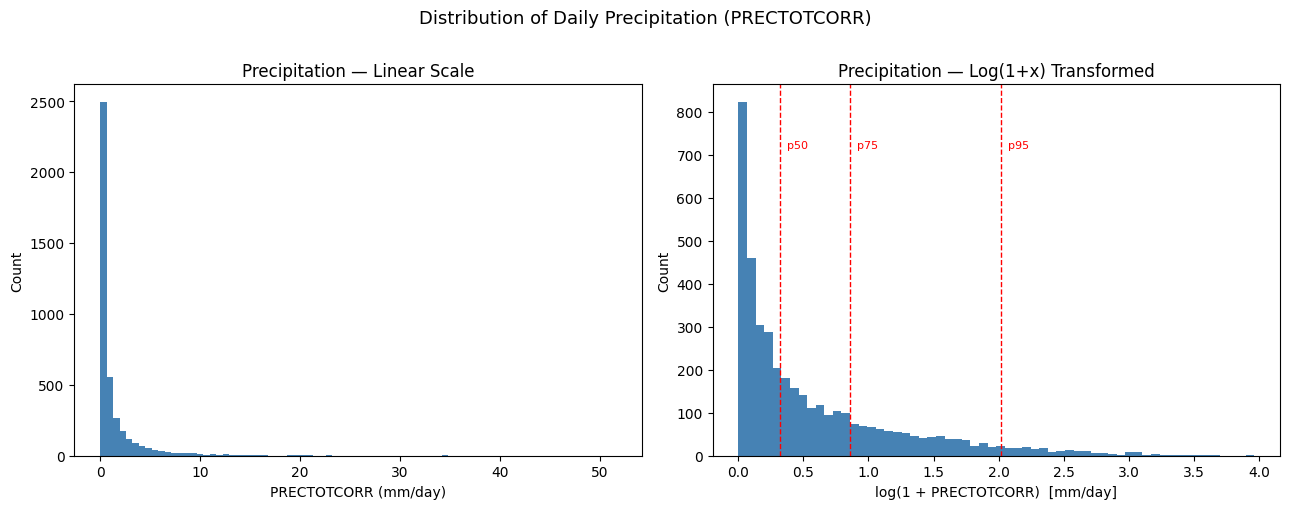

Skewness (raw):        5.51
Skewness (log1p):      1.59
% days with 0 mm:      6.3%
% days with < 1 mm:    68.9%
% days with ≥ 10 mm:   2.5%


In [99]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: linear scale ---
axes[0].hist(df["PRECTOTCORR"], bins=80, color="steelblue", edgecolor="none")
axes[0].set_xlabel("PRECTOTCORR (mm/day)")
axes[0].set_ylabel("Count")
axes[0].set_title("Precipitation — Linear Scale")

# --- Right: log1p y-axis (handles zero-rainfall days) ---
log_vals = np.log1p(df["PRECTOTCORR"])
axes[1].hist(log_vals, bins=60, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log(1 + PRECTOTCORR)  [mm/day]")
axes[1].set_ylabel("Count")
axes[1].set_title("Precipitation — Log(1+x) Transformed")

# Annotate key percentiles on the log plot
for pct, label in [(50, "p50"), (75, "p75"), (95, "p95")]:
    val = np.log1p(np.percentile(df["PRECTOTCORR"].dropna(), pct))
    axes[1].axvline(val, color="red", linewidth=1, linestyle="--")
    axes[1].text(val + 0.05, axes[1].get_ylim()[1] * 0.85, label,
                 color="red", fontsize=8, va="top")

plt.suptitle("Distribution of Daily Precipitation (PRECTOTCORR)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Skewness (raw):        {df['PRECTOTCORR'].skew():.2f}")
print(f"Skewness (log1p):      {log_vals.skew():.2f}")
print(f"% days with 0 mm:      {(df['PRECTOTCORR'] == 0).mean()*100:.1f}%")
print(f"% days with < 1 mm:    {(df['PRECTOTCORR'] < 1).mean()*100:.1f}%")
print(f"% days with ≥ 10 mm:   {(df['PRECTOTCORR'] >= 10).mean()*100:.1f}%")

## Precipitation Distribution — Shape Commentary

Rainfall is highly right-skewed (skewness = 5.51): the vast majority of days
are dry or nearly dry, while a small number of intense rain events pull the
tail far to the right. Specifically:

- **68.9% of days receive less than 1 mm** — effectively dry days with no
  meaningful rainfall.
- **Only 2.5% of days reach ≥ 10 mm** — these heavy events are rare but
  likely account for a disproportionate share of total annual rainfall.
- **6.3% of days record exactly 0 mm**, consistent with Kenya's pronounced
  dry seasons between the long and short rains.

Applying a log1p transformation reduces skewness from 5.51 to 1.59,
bringing the distribution closer to normal — useful for any statistical
modelling that assumes normality, but the raw values should be used for
climatological totals and seasonal comparisons.


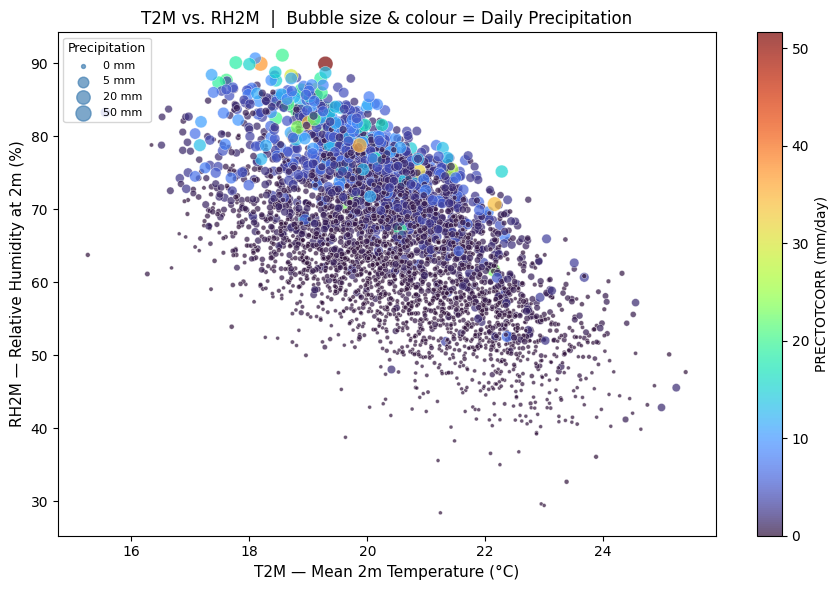

In [101]:
fig, ax = plt.subplots(figsize=(9, 6))

# Scale bubble area: log1p so zero-rain days don't vanish entirely
bubble_size = np.log1p(df["PRECTOTCORR"]) * 28 + 8

sc = ax.scatter(
    df["T2M"],
    df["RH2M"],
    s=bubble_size,
    c=df["PRECTOTCORR"],
    cmap="turbo",
    alpha=0.70,
    edgecolors="white",
    linewidths=0.35,
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("PRECTOTCORR (mm/day)", fontsize=10)

ax.set_xlabel("T2M — Mean 2m Temperature (°C)", fontsize=11)
ax.set_ylabel("RH2M — Relative Humidity at 2m (%)", fontsize=11)
ax.set_title("T2M vs. RH2M  |  Bubble size & colour = Daily Precipitation", fontsize=12)

# Legend for bubble size
for rain_val, label in [(0, "0 mm"), (5, "5 mm"), (20, "20 mm"), (50, "50 mm")]:
    ax.scatter([], [], s=np.log1p(rain_val) * 28 + 8,
               color="steelblue", alpha=0.7, label=label)
ax.legend(title="Precipitation", loc="upper left", fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()

## Bubble Chart — Distribution Shape

**Overall shape — negative diagonal band:** The point cloud stretches from upper-left (low T2M ≈ 15–17 °C, high RH ≈ 80–90 %) to lower-right (high T2M ≈ 23–25 °C, low RH ≈ 30–50 %), confirming a clear inverse relationship between temperature and humidity across all conditions.

**Rainy-day clustering (large red/yellow bubbles):** The largest, brightest bubbles — representing the heaviest rainfall events (> 20 mm/day) — concentrate in the upper-left quadrant around 17–21 °C and RH > 75 %. Rain-bearing systems advect cool, moist air into the region, simultaneously depressing temperature and elevating humidity.

**Dry-day mass (small grey dots):** The dense grey core spanning 19–23 °C and 50–75 % RH represents the majority of the record — days with negligible rainfall. This band forms the structural backbone of the negative trend and reflects Kenya's prevailing dry-season climate state.

**Triangular void (upper-right):** No points combine high temperature (> 23 °C) with high humidity (> 75 %). High temperatures drive boundary-layer mixing and suppress relative humidity, making this region of the parameter space physically inaccessible.

**Wedge-shaped spread:** RH variability is widest at low temperatures and narrows progressively as temperature rises, giving the cloud a wedge profile. At cool temperatures, humidity depends heavily on whether a rain system is present; at high temperatures, humidity is consistently suppressed regardless of season.